# Study the défi TextMine dataset

In [1]:
!pip install torch
!pip install transformers
!pip install scikit-learn
!pip install datasets
!pip install matplotlib
!pip install thefuzz

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 78.6 MB/s eta 0:00:00


In [2]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import json
import csv
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import re
import seaborn as sns
import networkx as nx
# pour comparer les string qui sont pratiquement la méme chose mais en des difference subtile
# qui empéche un matching exacte (exemple: Passage et Passages). Algo : Distance de Levenshtein
from thefuzz import fuzz

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
# Path to the folder in your Google Drive
# Note: If the folder is inside another folder, you'll need to add that to the path
import os

drive_path = '/content/drive/MyDrive/Colab Notebooks/Stage M1 IRIT/defi-text-mine-egc-2026'

train_dataset = []
test_dataset = []

# Load train data
train_file_path = os.path.join(drive_path, 'train_v2.jsonl')
with open(train_file_path, 'r', encoding='utf-8') as file:
    for line in file:
        train_dataset.append(json.loads(line))

# Load test data
test_file_path = os.path.join(drive_path, 'test_v4.jsonl')
with open(test_file_path, 'r', encoding='utf-8') as file:
    for line in file:
        test_dataset.append(json.loads(line))

print(f"Loaded {len(train_dataset)} training samples.")
print(f"Loaded {len(test_dataset)} test samples.")
if train_dataset:
    print("Keys:", train_dataset[0].keys())

Loaded 492 training samples.
Loaded 519 test samples.
Keys: dict_keys(['text', 'acronym', 'options'])


In [6]:
train_df = pd.DataFrame(train_dataset)
test_df = pd.DataFrame(test_dataset)
train_df

,text,acronym,options
0,LRA limite de résistance des attelages PAR po...,PAR,"{'Plan d'action régularité': False, 'Poste d'a..."
1,Désigna -tion des PN,PN,"{'Passages à niveau : fichier des pn, recensem..."
2,prédéterminées de trains : _x0001_ les masses ...,EM,"{'EMERAINVILLE PONTAULT COMBAULT': False, 'Eng..."
3,/Commentaires N° AC B81500 thermique: compati...,AC,"{'ACcès': False, 'Agent d'aCcompagnement ': Fa..."
4,"kilomètres/heure (ex : 12 pour 120 km/h), _x00...",TIV,"{'THIVIERS': False, 'Trafic international voya..."
...,...,...,...
487,teur des quais est ≥ 760 mm.] [ 1500V : (Lyon ...,US,"{'US (Val-d'Oise)': False, 'Unité simple : mod..."
488,série considérée sans risque de détérioration ...,RFF,"{'ROSCOFF': False, 'Réseau férré de france': T..."
489,figurant pas dans la CLE propre à l'établissem...,CLE,"{'CLERMONT FERRAND': False, 'Consigne Locale d..."
490,Km fin Restrictions ME120 ME100 MA100 830000 L...,CMT,"{'Contrôle des Mobiles Travaux': False, 'Contr..."


In [7]:
train_length = len(train_dataset)

row_stat = [{"nb_words_in_text":0, "nb_options":0, "related_texts": []} for _ in range(train_length)]

In [8]:
min_overlap_length_to_be_related = 6

def is_subsequence(sub, main):
    """Vérifie si la liste 'sub' est une sous-séquence de 'main'"""
    n, m = len(sub), len(main)
    for i in range(m - n + 1):
        if main[i : i + n] == sub:
            return True
    return False

true_vals_per_row = []
false_vals_per_row = []

for index, row in enumerate(train_dataset):
  # True and False Stats building
  true_vals_in_current_row = []
  false_vals_in_current_row = []
  for key, val in row["options"].items():
    if val: true_vals_in_current_row.append(key)
    else: false_vals_in_current_row.append(key)

  nb_true_in_current_line = len(true_vals_in_current_row)
  nb_false_in_current_line = len(false_vals_in_current_row)

  true_vals_per_row.append(nb_true_in_current_line)
  false_vals_per_row.append(nb_false_in_current_line)

  # Row Stat building
  words_in_current_text = [word for word in row["text"].strip().split(" ") if len(word)!=0]
  nb_options_in_current_row = len(row["options"].keys())

  related_texts = []

  for other_row_local_index, other_row in enumerate(train_dataset[index+1:]):
    words_in_other_text = [word for word in other_row["text"].strip().split(" ") if len(word)!=0]

    for i in range(len(words_in_current_text) - min_overlap_length_to_be_related):
      sub_seq = words_in_current_text[i:i + min_overlap_length_to_be_related]
      if is_subsequence(sub_seq, words_in_other_text):
        other_row_global_index = index + 1 + other_row_local_index

        related_texts.append(other_row_global_index)
        row_stat[other_row_global_index]["related_texts"].append(index)
        break

  row_stat[index]["nb_words_in_text"] = len(words_in_current_text)
  row_stat[index]["nb_options"] = nb_options_in_current_row
  row_stat[index]["related_texts"] += related_texts


In [9]:
acronym_info = {}

for index, row in enumerate(train_dataset):
  nb_true_in_current_line = true_vals_per_row[index]
  nb_false_in_current_line = false_vals_per_row[index]

  # Stat Acronym Collection building
  if row["acronym"] not in acronym_info:
    acronym_info[row["acronym"]] = {}

    acronym_info[row["acronym"]]["nb_total"] = 1
    acronym_info[row["acronym"]]["nb_per_text"] = [(index, len(re.findall(re.compile(row["acronym"]), row["text"])))]
    acronym_info[row["acronym"]]["variations"] = set(row["options"].keys())

    acronym_info[row["acronym"]]["Total True"] = nb_true_in_current_line
    acronym_info[row["acronym"]]["Total False"] = nb_false_in_current_line
    acronym_info[row["acronym"]]["True/False"] = {}
    acronym_info[row["acronym"]]["True/False"][index] = {"True": nb_true_in_current_line, "False": nb_false_in_current_line}
  else:
    acronym_info[row["acronym"]]["nb_total"] += 1
    acronym_info[row["acronym"]]["nb_per_text"].append((index, len(re.findall(re.compile(row["acronym"]), row["text"]))))
    acronym_info[row["acronym"]]["variations"].update(row["options"].keys())

    acronym_info[row["acronym"]]["Total True"] += len(true_vals_in_current_row)
    acronym_info[row["acronym"]]["Total False"] += len(false_vals_in_current_row)
    acronym_info[row["acronym"]]["True/False"][index] = {"True": nb_true_in_current_line, "False": nb_false_in_current_line}

# Stat Acronym Prep before DataFraming
acronym_stats = []
for key, val in acronym_info.items():
  acronym_stats.append({
      "acronym": key,
      "nb total mentions throught different rows": val["nb_total"],
      "nb total mentions in text": sum([nb_row for _, nb_row in val["nb_per_text"]]),
      "mentions in text": val["nb_per_text"],
      "num_variations": len(val["variations"]),
      "variations": val["variations"],
      "Total True": val["Total True"],
      "Total False": val["Total False"],
      "True/False": val["True/False"]

  })

In [10]:
# getting the rows that part of the same doc
def group_connected_obj(data_iterable, refs_key_in_data_iterable, refs_key_in_output_dict):
  docs = []
  for row_index, row in enumerate(data_iterable):
    # Update the docs with the 'related_texts' of a row if it is found to be part of a specific doc from iy
    in_docs_indexes = [] # keep track of how many docs this row connectes
    for doc_index, doc in enumerate(docs):
      if row_index in doc[refs_key_in_output_dict]:
        doc[refs_key_in_output_dict].update(row[refs_key_in_data_iterable])
        in_docs_indexes.append(doc_index)

    # if never mentioned then create a new doc for it in docs
    if len(in_docs_indexes) == 0:
      new_doc = {
          refs_key_in_output_dict: set(row[refs_key_in_data_iterable] + [row_index])
      }
      docs.append(new_doc)

    # if mentioned in 2 or more docs. then merge those docs into the first one
    elif len(in_docs_indexes) > 1:
      docs_copy = docs.copy()
      for related_doc_index_offset, related_doc_index in enumerate(in_docs_indexes[1:]):
        docs[in_docs_indexes[0]][refs_key_in_output_dict].update(docs_copy[related_doc_index][refs_key_in_output_dict])
        docs.pop(related_doc_index - related_doc_index_offset) # a chaque suppresion l'index et decrementer de 1 (offseter) pour rester correct

  return docs

docs = group_connected_obj(row_stat, "related_texts", "refs")


In [11]:
options_info = {}
Threshold_for_similar_options = 89 # % 100

# Uses Fuzzy Matching to get the score of most similair substring shared between the two
def is_substring(str1, str2):
  score = fuzz.partial_ratio(str1.lower(), str2.lower())
  return score

# options_info Collection building
for index, row in enumerate(train_dataset):
  for op, val in row["options"].items():
    true_val = int(val)
    false_val = 1 - true_val

    if op not in options_info:
      options_info[op] = {}
      options_info[op]["nb_trues"] = true_val
      options_info[op]["nb_falses"] = false_val
      options_info[op]["nb_variations"] = 0
      options_info[op]["variations"] = []
    else:
      options_info[op]["nb_trues"] += true_val
      options_info[op]["nb_falses"] += false_val

options = list(options_info.keys())
# Here I add things that should be together. for example, I know after this that all the "Pas un acronyme..." stuff will come under this umbrella
added_options = ["Pas un acronyme"]
options += added_options
options.sort(key=lambda s: len(s))
options = list(filter(lambda x: len(x) > 4, options))

already_in_list = []
for op_index, op in enumerate(options):
  if op_index not in already_in_list:
    for other_op_index, other_op in enumerate(options[op_index + 1:]):
      if is_substring(op, other_op) >= Threshold_for_similar_options:
        if op in options_info:
          options_info[op]["nb_variations"] += 1
          options_info[op]["variations"].append(other_op)
        else:
          # This is for the "added_options" to view all the variations and groupe them here
          options_info[op] = {}
          options_info[op]["nb_trues"] = 0
          options_info[op]["nb_falses"] = 0
          options_info[op]["nb_variations"] = 1
          options_info[op]["variations"] = [other_op]

        already_in_list.append(op_index + 1 + other_op_index)
# Stat options Prep before DataFraming
options_stat = []
for op, vals in options_info.items():
  options_stat.append({
      "option": op,
      "nb_trues": vals["nb_trues"],
      "nb_false": vals["nb_falses"],
      "nb_variations": vals["nb_variations"],
      "variations": vals["variations"]
  })

In [12]:
options_stat_df = pd.DataFrame(options_stat)
display(options_stat_df)

# Filter rows where there are variations
filtred_by_num = options_stat_df.loc[options_stat_df["nb_variations"] > 0]
display(filtred_by_num)

# Use .apply() to execute the function on each string in the 'option' column
mask = options_stat_df['option'].apply(lambda x: is_substring(x, "Pas un acronyme") > Threshold_for_similar_options)
filtred = options_stat_df.loc[mask]

display(filtred)

,option,nb_trues,nb_false,nb_variations,variations
0,Plan d'action régularité,0,6,0,[]
1,Poste d'aiguillage et de régulation : assure l...,5,1,0,[]
2,PONT DE L'ARCHE,0,6,0,[]
3,Plan d'action régional,0,6,0,[]
4,"Passages à niveau : fichier des pn, recensemen...",5,16,0,[]
...,...,...,...,...,...
335,Contrôle des Mobiles Travaux,0,1,0,[]
336,Contrat Multi Technique,0,1,0,[]
337,Connaissance et maîtrise du territoire,0,1,0,[]
338,CHAMP-ST-PÈRE,0,1,0,[]


,option,nb_trues,nb_false,nb_variations,variations
10,Passage à Niveau,18,3,1,"[Passages à niveau : fichier des pn, recenseme..."
13,Emetteur,0,24,1,[Transmetteur]
48,Central Sous Station,9,0,1,[Régulateur Sous Stations : Agent chargé à par...
91,Raccordement Nord,1,0,1,[RACCORDEMENT de FOLLIGNY OUEST ]
92,ROUEN rive droite,0,1,1,[Rouen Rive Droite ]
98,En tension,0,2,1,[Transformateur de tension]
116,Commande Centralisée des Trains,1,0,2,"[Commande Centralisée du Trafic., Commande Cen..."
130,Détonateur,0,11,1,[Poste d'aiguillage informatisé : la saisie de...
141,Relation grand parcours,0,1,2,"[Relation à grand parcours, Éléments automoteu..."
146,Infrastructure,1,0,9,"[Direction régionale infrastructure, Attestati..."


,option,nb_trues,nb_false,nb_variations,variations
105,"Pas un acronyme, ""et"" en majuscule",1,0,0,[]
195,"Pas un acronyme, ""de"" en majuscule",2,0,0,[]
242,Pas un acronyme : chiffre 4 en chiffre romain,1,0,0,[]
329,"Pas un acronyme, c'est du = de le : ""Du km… au...",1,0,0,[]
339,Pas un acronyme,0,0,4,"[Pas un acronyme, ""et"" en majuscule, Pas un ac..."


In [13]:
row_stat_df = pd.DataFrame(row_stat)
display(row_stat_df)
print("Nb moyen de mot dans un texte :", row_stat_df["nb_words_in_text"].mean())
print("Nb moyen d'option pour un texte :", row_stat_df["nb_options"].mean())


,nb_words_in_text,nb_options,related_texts
0,23,4,"[42, 47, 50, 51, 53, 56, 71, 72, 89, 106, 107,..."
1,4,7,[]
2,52,6,"[31, 43, 70, 88, 95, 101, 113, 208]"
3,28,10,"[28, 105, 110, 139, 141, 153, 165, 210, 215, 2..."
4,46,3,"[17, 57, 94, 152, 170, 268, 387, 451, 483]"
...,...,...,...
487,51,4,"[3, 28, 105, 110, 139, 141, 153, 165, 210, 215..."
488,23,2,"[331, 352, 353, 442]"
489,45,2,"[12, 49, 120, 133, 166, 189, 217, 241, 254, 26..."
490,96,4,[]


Nb moyen de mot dans un texte : 32.42886178861789
Nb moyen d'option pour un texte : 4.42479674796748


In [14]:
articles_info = {}
# Pattern to capture root (e.g. A503) and optional sub-point (e.g. .9)
article_pattern = re.compile(r'(A\d+)(?:\.(\d+))?|(Article\s?\d+)', re.IGNORECASE)

for index, row in enumerate(train_dataset):
    found = article_pattern.findall(row['text'])
    doc_id = next((i for i, d in enumerate(docs) if index in d['refs']), None)

    for root_a, sub_a, art_word in found:
        # Normalize root name
        root = root_a if root_a else art_word
        sub = sub_a if sub_a else "0"

        if root not in articles_info:
            articles_info[root] = {
                "root_name": root,
                "total_mentions": 0,
                "sub_points": set(),
                "row_indices": set(),
                "doc_ids": set()
            }

        articles_info[root]["total_mentions"] += 1
        articles_info[root]["sub_points"].add(sub)
        articles_info[root]["row_indices"].add(index)
        if doc_id is not None: articles_info[root]["doc_ids"].add(doc_id)

# Formatting for display
articles_stats_list = []
for root, info in articles_info.items():
    articles_stats_list.append({
        "article_root": root,
        "nb_mentions": info["total_mentions"],
        "sub_points_found": sorted(list(info["sub_points"])),
        "nb_unique_rows": len(info["row_indices"]),
        "row_indices": sorted(list(info["row_indices"])),
        "docs": list(info["doc_ids"])
    })

articles_df = pd.DataFrame(articles_stats_list).sort_values(by="nb_mentions", ascending=False)
display(articles_df)

,article_root,nb_mentions,sub_points_found,nb_unique_rows,row_indices,docs
3,A503,28,"[0, 1, 10, 11, 12, 2, 6, 8, 9]",23,"[12, 49, 120, 127, 133, 138, 166, 189, 217, 24...","[32, 0, 37, 7]"
1,A105,8,"[0, 1, 2]",4,"[6, 10, 325, 367]","[9, 75, 6]"
4,article 10,7,[0],7,"[40, 83, 182, 195, 212, 246, 395]",[18]
2,A504,7,[0],7,"[8, 38, 143, 154, 200, 241, 254]",[7]
5,A502,6,[0],6,"[68, 75, 103, 163, 248, 305]","[24, 59]"
9,A100,4,[0],4,"[128, 205, 355, 490]","[33, 2, 44, 98]"
13,A301,4,"[1, 3]",4,"[194, 216, 315, 344]","[66, 51]"
0,A104,2,[0],2,"[6, 276]",[6]
12,A402,2,[0],2,"[160, 394]","[83, 43]"
7,A80,2,[0],2,"[128, 205]","[33, 44]"


In [38]:
target_word = "Réservé"
# Case-insensitive search for the word
pattern = re.compile(rf'\b{target_word}\b', re.IGNORECASE)

reserved_stats = []

for index, row in enumerate(train_dataset):
    text = row['text']
    matches = pattern.findall(text)
    count = len(matches)

    if count > 0:
        # Find which doc this row belongs to
        doc_id = next((i for i, d in enumerate(docs) if index in d['refs']), None)

        reserved_stats.append({
            "row_index": index,
            "doc_id": doc_id,
            "mentions_in_row": count,
            "text_snippet": text[:100] + "..." # Context snippet
        })

reserved_df = pd.DataFrame(reserved_stats)

if not reserved_df.empty:
    total_mentions = reserved_df['mentions_in_row'].sum()
    total_rows_with_word = len(reserved_df)

    # Grouping by Document
    doc_summary = reserved_df.groupby('doc_id').agg(
        nb_rows_involved=('row_index', 'count'),
        total_mentions_in_doc=('mentions_in_row', 'sum')
    ).sort_values(by='total_mentions_in_doc', ascending=False)

    print(f"--- Global Stats for '{target_word}' ---")
    print(f"Total absolute occurrences: {total_mentions}")
    print(f"Total rows containing the word: {total_rows_with_word}")
    print(f"Average mentions per active row: {total_mentions / total_rows_with_word:.2f}")

    print("\n--- Top Documents containing 'Réservé' ---")
    display(doc_summary.head(10))

    print("\n--- Row-level Detail (Top 5) ---")
    display(reserved_df.sort_values(by='mentions_in_row', ascending=False))
else:
    print(f"The term '{target_word}' was not found in the training dataset.")

--- Global Stats for 'Réservé' ---
Total absolute occurrences: 21
Total rows containing the word: 19
Average mentions per active row: 1.11

--- Top Documents containing 'Réservé' ---


,nb_rows_involved,total_mentions_in_doc
doc_id,,
7,14,16
2,1,1
6,1,1
56,1,1
62,1,1
94,1,1



--- Row-level Detail (Top 5) ---


,row_index,doc_id,mentions_in_row,text_snippet
3,120,7,2,Réservé. A503.9 Dispositions relatives au dépa...
7,241,7,2,Réservé A503.12 Dispositions relatives à la ré...
0,12,7,1,Réservé. A503.9 Dispositions relatives au dépa...
2,49,7,1,A503.8 Obligation ou interdiction d'usage des ...
1,38,7,1,Réservé Article A504 Passages à niveau (sauf ...
5,166,7,1,de boudin ou de rails Réservé. A503.9 Disposit...
4,154,7,1,Réservé Article A504 Passages à niveau (sauf ...
6,217,7,1,de boudin ou de rails Réservé. A503.9 Disposit...
8,243,56,1,Article A506 Autres particularités Réservé. In...
9,254,7,1,A503.12 Dispositions relatives à la réception ...


In [39]:
# List of major French cities/towns relevant to SNCF network
cities_to_track = [
    'Paris', 'Marseille', 'Lyon', 'Toulouse', 'Nice', 'Nantes', 'Montpellier',
    'Strasbourg', 'Bordeaux', 'Lille', 'Rennes', 'Reims', 'Saint-Étienne',
    'Le Havre', 'Toulon', 'Grenoble', 'Dijon', 'Angers', 'Nîmes', 'Villeurbanne',
    'Le Mans', 'Aix-en-Provence', 'Clermont-Ferrand', 'Brest', 'Tours', 'Amiens',
    'Limoges', 'Annecy', 'Perpignan', 'Boulogne-Billancourt', 'Metz', 'Besançon',
    'Orléans', 'Saint-Denis', 'Argenteuil', 'Mulhouse', 'Rouen', 'Caen', 'Nancy',
    'Valence', 'Avignon', 'Poitiers', 'Pau', 'Antibes', 'Béziers', 'La Rochelle',
    'Cannes', 'Saint-Nazaire', 'Colmar', 'Bourges', 'Quimper', 'Dunkerque',
    'Aubervilliers', 'Cherbourg', 'Vénissieux', 'Lorient', 'Chambéry', 'Niort'
]

city_mentions = {}

for index, row in enumerate(train_dataset):
    text = row['text']
    doc_id = next((i for i, d in enumerate(docs) if index in d['refs']), None)

    for city in cities_to_track:
        # Using word boundaries to avoid partial matches (e.g., 'Pau' in 'Epaul')
        matches = re.findall(rf'\b{city}\b', text, re.IGNORECASE)
        if matches:
            if city not in city_mentions:
                city_mentions[city] = {
                    "total_occurences": 0,
                    "rows": set(),
                    "docs": set()
                }
            city_mentions[city]["total_occurences"] += len(matches)
            city_mentions[city]["rows"].add(index)
            if doc_id is not None: city_mentions[city]["docs"].add(doc_id)

# Formatting for DataFrame
city_stats = []
for city, stats in city_mentions.items():
    city_stats.append({
        "City": city,
        "Total Mentions": stats["total_occurences"],
        "Nb Unique Rows": len(stats["rows"]),
        "Nb Unique Docs": len(stats["docs"]),
        "Document IDs": sorted(list(stats["docs"])),
        "Row Indices": sorted(list(stats["rows"]))
    })

city_df = pd.DataFrame(city_stats).sort_values(by="Total Mentions", ascending=False)

print("--- Top Mentioned Cities ---")
display(city_df.head(15))

# Analysis by Document: Which doc is most 'geographic'?
doc_geo_density = {}
for city, stats in city_mentions.items():
    for d_id in stats["docs"]:
        doc_geo_density[d_id] = doc_geo_density.get(d_id, 0) + 1

geo_docs_df = pd.DataFrame([
    {"doc_id": k, "unique_cities_count": v} for k, v in doc_geo_density.items()
]).sort_values(by="unique_cities_count", ascending=False)

print("\n--- Documents mentioning the most unique cities ---")
display(geo_docs_df.head(10))

--- Top Mentioned Cities ---


,City,Total Mentions,Nb Unique Rows,Nb Unique Docs,Document IDs,Row Indices
2,Lyon,42,26,15,"[3, 6, 14, 21, 22, 24, 45, 54, 61, 62, 63, 65,...","[46, 55, 67, 68, 75, 84, 103, 118, 163, 167, 1..."
1,Paris,17,12,9,"[0, 3, 15, 22, 26, 32, 37, 59, 81]","[46, 127, 138, 174, 230, 248, 250, 305, 320, 3..."
0,Chambéry,7,7,4,"[3, 8, 24, 80]","[9, 68, 103, 163, 311, 383, 466]"
3,Valence,6,4,4,"[6, 22, 25, 73]","[78, 330, 349, 370]"
5,Lille,6,4,3,"[10, 46, 55]","[129, 176, 239, 385]"
4,La Rochelle,2,2,1,[28],"[104, 409]"
7,Tours,2,1,1,[41],[226]
11,Vénissieux,2,1,1,[98],[490]
6,Limoges,1,1,1,[21],[201]
8,Dijon,1,1,1,[58],[245]



--- Documents mentioning the most unique cities ---


,doc_id,unique_cities_count
2,3,4
9,22,3
3,80,2
13,98,2
6,37,2
1,24,2
15,73,2
18,21,2
14,6,2
5,0,1


In [45]:
docs_df = pd.DataFrame(docs)
# display(docs_df)

mask_docs = docs_df["refs"].apply(lambda x: len(x) > 1)
filtred_docs = docs_df.loc[mask_docs]
# display(filtred_docs)
# print(filtred_docs.size)

docs_df = docs_df.sort_values(by="refs", key=lambda refs: pd.Series([len(obj) for obj in refs]), ascending=False)
docs_df

,refs
0,"{0, 7, 13, 14, 16, 24, 25, 34, 36, 41, 42, 44,..."
3,"{3, 272, 279, 280, 26, 28, 302, 311, 314, 316,..."
7,"{258, 386, 133, 8, 12, 269, 270, 143, 407, 154..."
10,"{129, 390, 11, 274, 281, 285, 30, 288, 304, 18..."
12,"{64, 136, 299, 77, 238, 336, 474, 18, 54, 184,..."
...,...
94,{441}
95,{457}
96,{465}
97,{468}


In [40]:
acronym_stats_df = pd.DataFrame(acronym_stats)
display(acronym_stats_df)
trues_and_falses_df = pd.DataFrame({"True":true_vals_per_row, "False": false_vals_per_row})
display(trues_and_falses_df)

,acronym,nb total mentions throught different rows,nb total mentions in text,mentions in text,num_variations,variations,Total True,Total False,True/False
0,PAR,6,6,"[(0, 1), (50, 1), (75, 1), (103, 1), (117, 1),...",5,"{Plan d'action régional, Préposition ""par"", Po...",6,8,"{0: {'True': 1, 'False': 3}, 50: {'True': 1, '..."
1,PN,21,25,"[(1, 1), (8, 1), (47, 1), (51, 1), (56, 1), (7...",7,"{Paris Nord, Passage à Niveau, Passages à nive...",21,26,"{1: {'True': 1, 'False': 6}, 8: {'True': 1, 'F..."
2,EM,24,24,"[(2, 1), (13, 1), (25, 1), (43, 1), (65, 1), (...",6,"{électro-magnétique, État membre, EMERAINVILLE...",24,28,"{2: {'True': 1, 'False': 5}, 13: {'True': 1, '..."
3,AC,29,29,"[(3, 1), (20, 1), (26, 1), (73, 1), (76, 1), (...",10,"{Amélioration Continue, Accord Cadre, ACcès, A...",28,38,"{3: {'True': 0, 'False': 10}, 20: {'True': 0, ..."
4,TIV,17,27,"[(4, 2), (17, 2), (57, 2), (94, 2), (97, 1), (...",3,"{THIVIERS, Tableau indicateur de vitesse, Traf...",17,18,"{4: {'True': 1, 'False': 2}, 17: {'True': 1, '..."
...,...,...,...,...,...,...,...,...,...
72,LV,1,1,"[(437, 1)]",2,"{LYON VAISE, Ligne de voie}",1,1,"{437: {'True': 1, 'False': 1}}"
73,PAI,1,1,"[(456, 1)]",4,"{Permanent Acheminement Infra, Provision pour ...",1,3,"{456: {'True': 1, 'False': 3}}"
74,STI,1,1,"[(457, 1)]",6,"{Subdivision terminale intérieur, Spécificatio...",1,5,"{457: {'True': 1, 'False': 5}}"
75,DU,1,1,"[(468, 1)]",7,"{Dirigeant d'unité, Diagramme d'Utilisation, P...",1,6,"{468: {'True': 1, 'False': 6}}"


,True,False
0,1,3
1,1,6
2,1,5
3,0,10
4,1,2
...,...,...
487,1,3
488,1,1
489,1,1
490,0,4


In [19]:
# Equivalent data type for a DataFrame
test_pd = {
    'Name': ['Alice', 'Bob', 'Charlie'],
    'Age': [25, 30, 35],
    'City': ['NY', 'LA', 'SF']
    }
test_pd_2 = [
    {"Name": "Alice", "Age": 25, "City": "NY"},
    {"Name": "Bob", "Age": 30, "City": "LA"},
    {"Name": "Charlie", "Age": 35, "City": "SF"}
  ]

df_pd_test, df_pd_test2 = pd.DataFrame(test_pd), pd.DataFrame(test_pd_2)
display(df_pd_test)
display(df_pd_test2)

,Name,Age,City
0,Alice,25,NY
1,Bob,30,LA
2,Charlie,35,SF


,Name,Age,City
0,Alice,25,NY
1,Bob,30,LA
2,Charlie,35,SF


In [20]:
# =====================================================================
# GRAPHIQUE 1 : Graphe de Réseau (Reconstitution du Corpus)
# =====================================================================
def plot_network_corpus(docs_df, top_n=5):
    """
    Description : Génère un graphe de réseau (Network) reliant les documents sources
                  aux segments de texte (rows) qu'ils partagent.

    Utilité RAG (Attribution) : Démontre que le découpage n'est pas aléatoire.
    Permet de visualiser les "blocs" de texte cohérents pour tester le modèle NLI
    d'attribution sur des paragraphes complets plutôt que sur des phrases isolées.
    """
    # Trier le DataFrame en fonction de la taille de l'ensemble (set) dans 'refs'
    df_sorted = docs_df.copy()
    df_sorted['refs_len'] = df_sorted['refs'].apply(len)
    df_sorted = df_sorted.sort_values(by='refs_len', ascending=False).head(top_n)

    G = nx.Graph()

    for idx, row in df_sorted.iterrows():
        # Utiliser l'index du DataFrame original (ou l'ID) comme noeud Document
        doc_node = f"Doc #{idx}"
        G.add_node(doc_node, type='doc')

        # Extraire les références des lignes (limité à 15 pour la lisibilité)
        refs = list(row['refs'])[:15]
        for r_id in refs:
            row_node = f"Ligne {r_id}"
            G.add_node(row_node, type='row')
            G.add_edge(doc_node, row_node)

    # Définir les couleurs et tailles (Bleu pour les Docs, Gris pour les Rows)
    color_map = ['#0088CE' if G.nodes[node]['type'] == 'doc' else '#D1D5DB' for node in G]
    size_map = [1500 if G.nodes[node]['type'] == 'doc' else 300 for node in G]

    plt.figure(figsize=(10, 8))
    pos = nx.spring_layout(G, k=0.5) # Algorithme de placement pour écarter les noeuds
    nx.draw(G, pos, node_color=color_map, node_size=size_map, with_labels=True,
            font_size=8, font_weight='bold', edge_color='#9CA3AF')

    plt.title(f"Reconstitution du Corpus : Les {top_n} plus gros documents", fontsize=14, fontweight='bold')
    plt.show()


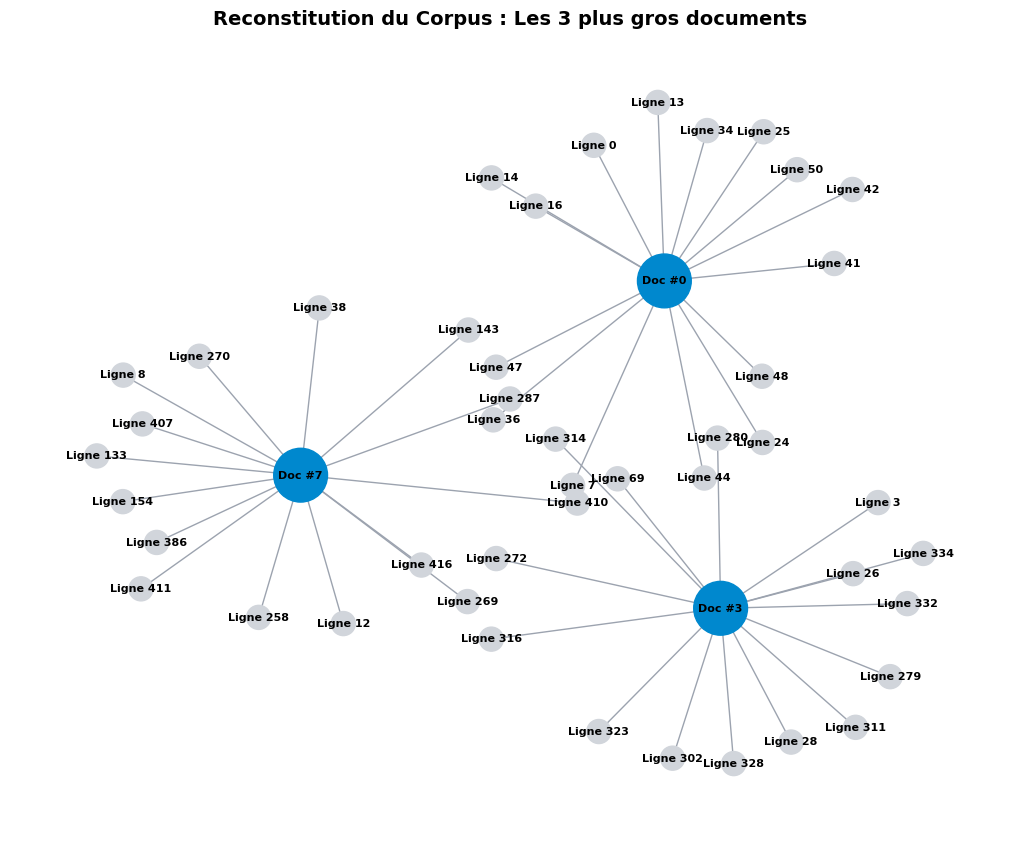

In [21]:
plot_network_corpus(docs_df, top_n=3)

In [22]:
# =====================================================================
# GRAPHIQUE 2 : Bar Chart Horizontal (L'Ancrage Réglementaire)
# =====================================================================
def plot_horizontal_bar_articles(articles_df, top_n=10):
    """
    Description : Affiche un diagramme à barres horizontal des articles les plus cités.

    Utilité RAG (Attribution) : Permet de repérer les articles majeurs et les mentions
    obsolètes (ex: "Réservé"). Idéal pour construire des requêtes pièges afin de
    vérifier si le LLM hallucine des procédures sur des articles vides.
    """
    df_top = articles_df.head(top_n).copy()
    df_top = df_top.iloc[::-1] # Inverser pour l'affichage

    plt.figure(figsize=(10, 6))
    bars = plt.barh(df_top['article_root'], df_top['nb_mentions'], color='#CD0037')

    plt.title(f"Top {top_n} des Articles Réglementaires les plus cités", fontsize=14, fontweight='bold')
    plt.xlabel("Nombre de mentions dans le corpus")
    plt.ylabel("Article / Référence")

    for bar in bars:
        plt.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
                 f'{int(bar.get_width())}', va='center', ha='left', fontsize=10)

    plt.tight_layout()
    plt.show()


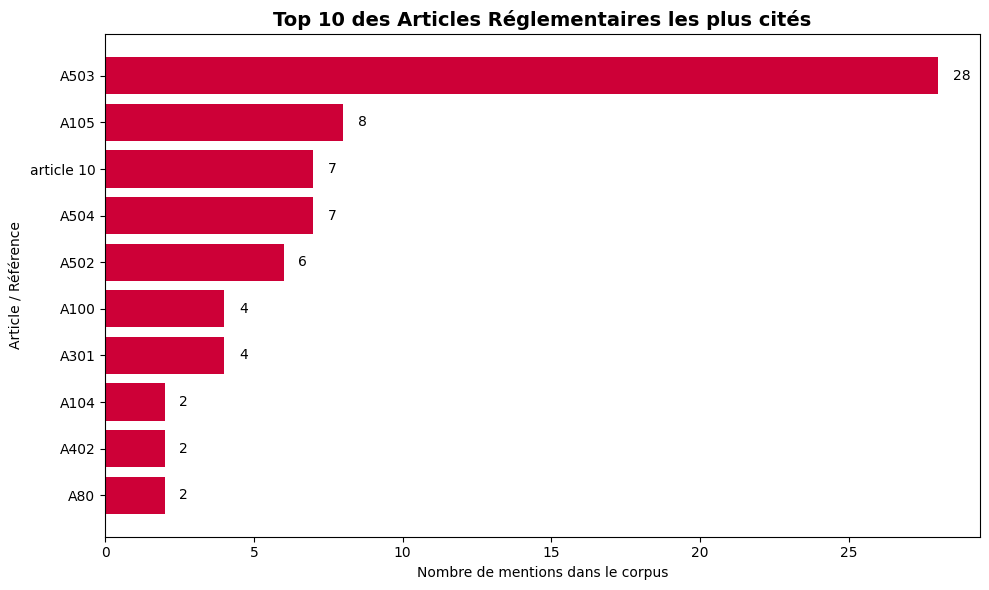

In [23]:
plot_horizontal_bar_articles(articles_df)

In [24]:
def plot_readable_city_heatmap(city_df, top_n_cities=12):
    """
    Description : Heatmap 1D basée sur city_df, montrant l'intensité des
                  mentions pour chaque ville avec un dégradé de couleurs.
    """
    if 'City' not in city_df.columns or 'Total Mentions' not in city_df.columns:
        print("⚠️ ERREUR : Le DataFrame ne contient pas les colonnes 'City' et 'Total Mentions'.")
        return

    # Prendre les N premières villes et utiliser 'City' comme index pour l'affichage
    df_top = city_df.head(top_n_cities).set_index('City')[['Total Mentions']]

    plt.figure(figsize=(5, 8))

    # Création d'une Heatmap à une seule colonne (1D)
    sns.heatmap(df_top, cmap="Reds", annot=True, fmt="d",
                linewidths=1, linecolor='lightgray',
                cbar_kws={'label': 'Nombre total de mentions'})

    plt.title(f"Intensité des mentions :\nTop {top_n_cities} Villes", fontsize=14, fontweight='bold', pad=20)
    plt.ylabel("Villes", fontsize=12, fontweight='bold')
    plt.xlabel("") # Pas besoin de label en X

    plt.yticks(rotation=0, fontsize=11)
    plt.xticks([]) # On cache l'axe X pour que ce soit plus propre

    plt.tight_layout()
    plt.show()

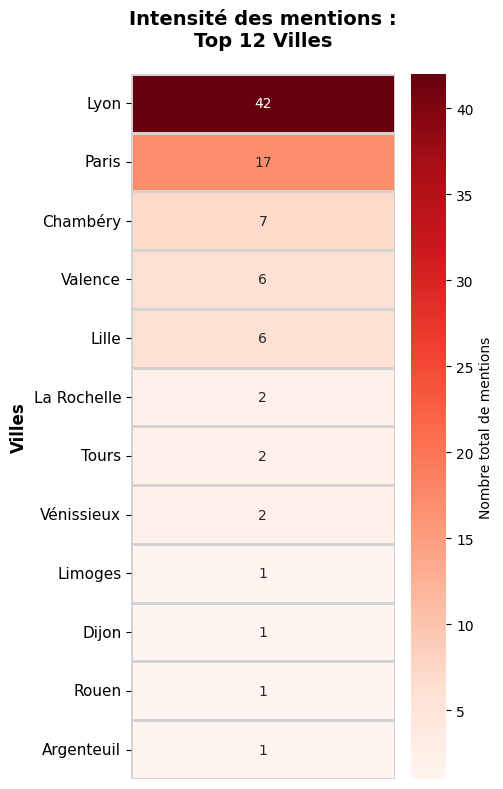

In [25]:
plot_readable_city_heatmap(city_df)

In [26]:
# =====================================================================
# GRAPHIQUE 3B : Bubble Chart (Analyse par Document Géographique)
# =====================================================================
def plot_city_bubble_chart(geo_docs_df, top_n=10):
    """
    Description : Utilise geo_docs_df. Affiche les Documents les plus "géographiques"
                  (ceux qui mentionnent le plus grand nombre de villes uniques).

    Utilité RAG (Attribution) : Détecter les documents "Carrefours". Un document
    qui mentionne 4 villes est une cible parfaite pour vérifier si le modèle d'attribution
    arrive à faire la part des choses entre plusieurs contextes géographiques locaux.
    """
    df_top = geo_docs_df.head(top_n).copy()
    # Convertir l'ID en chaîne pour un axe catégoriel propre
    df_top['doc_str'] = "Doc #" + df_top['doc_id'].astype(str)

    plt.figure(figsize=(12, 6))

    # La taille de la bulle représente la diversité géographique
    sizes = df_top['unique_cities_count'] * 400

    plt.scatter(df_top['doc_str'], df_top['unique_cities_count'], s=sizes,
                color='#8A9097', alpha=0.7, edgecolors="#333333", linewidth=2)

    plt.title(f"Diversité Géographique : Top {top_n} des Documents Multi-Villes", fontsize=14, fontweight='bold')
    plt.ylabel("Nombre de Villes Uniques mentionnées")
    plt.xlabel("ID du Document")

    # Ajuster la limite Y pour ne pas couper les bulles
    plt.ylim(0, df_top['unique_cities_count'].max() + 1)
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()


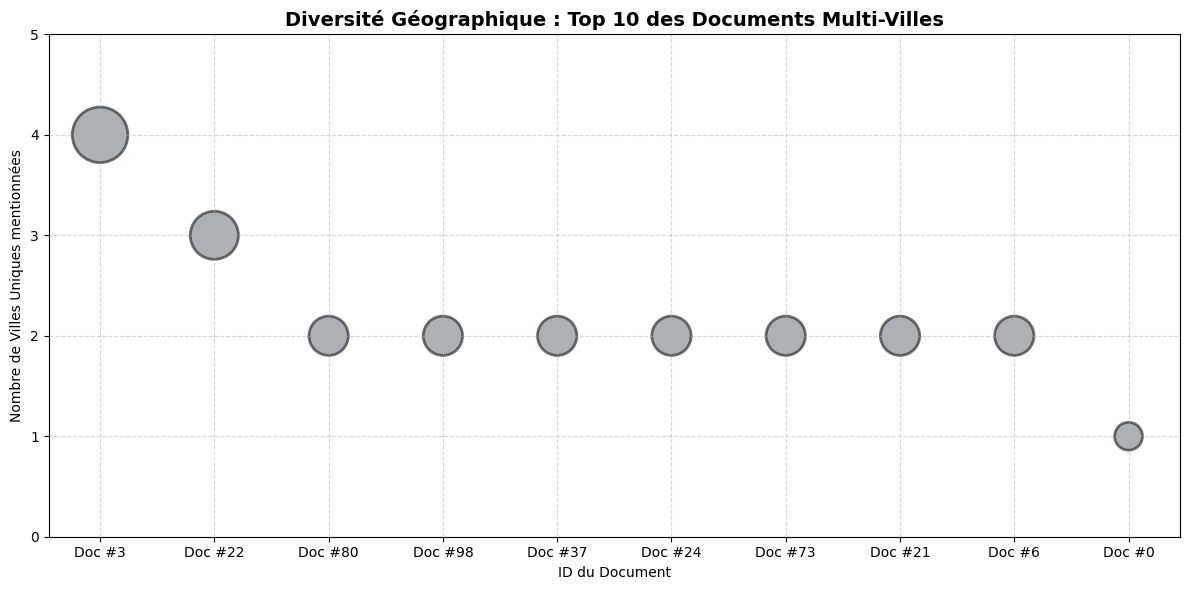

In [27]:
plot_city_bubble_chart(geo_docs_df)

In [28]:
# =====================================================================
# GRAPHIQUE 4 : Stacked Bar Chart (Ambiguïté / Acronymes)
# =====================================================================
def plot_stacked_bar_acronyms(acronym_df, top_n=10):
    """
    Description : Barres empilées montrant le ratio de définitions Vraies (Cibles)
                  vs Fausses (Bruit) pour les acronymes.

    Utilité RAG : Montre la difficulté de la désambiguïsation basique.
    """
    df_top = acronym_df.sort_values(by='Total False', ascending=False).head(top_n)

    fig, ax = plt.subplots(figsize=(12, 6))
    labels = df_top['acronym'] + " (" + df_top['num_variations'].astype(str) + " vars)"
    vrai_vals = df_top['Total True'].values
    faux_vals = df_top['Total False'].values

    ax.bar(labels, faux_vals, label='Définitions Fausses (Bruit)', color='#D1D5DB')
    ax.bar(labels, vrai_vals, bottom=faux_vals, label='Définitions Vraies (Cibles)', color='#0088CE')

    ax.set_ylabel('Nombre de propositions dans le Dataset')
    ax.set_title(f"Polysémie : Ratio Vrai/Faux pour les {top_n} acronymes les plus ambigus", fontsize=14, fontweight='bold')
    ax.legend()
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

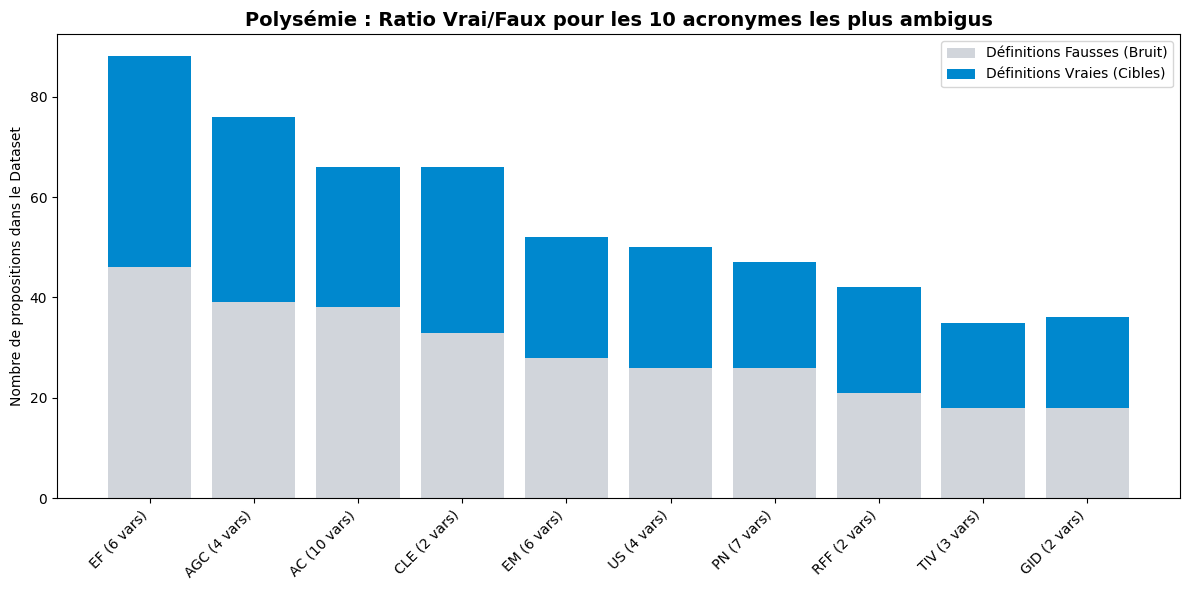

In [29]:
plot_stacked_bar_acronyms(acronym_stats_df)

In [30]:
# =====================================================================
# GRAPHIQUE 5 : Scatter Plot (Complexité des Acronymes) - NOUVEAU
# =====================================================================
def plot_acronym_complexity_scatter(acronym_df, top_n=20):
    """
    Description : Croise 3 dimensions d'un acronyme :
                  Axe X = Polysémie (Nb variations)
                  Axe Y = Bruit total (Nb d'options fausses)
                  Taille = Fréquence d'apparition dans les textes.

    Utilité RAG (Attribution) : C'est la carte aux trésors pour créer tes requêtes de test.
    Les bulles géantes situées en haut à droite sont les "Pires Cas" : elles apparaissent
    partout, ont plein de sens différents, et génèrent un bruit maximal.
    Idéal pour tester les limites du RAG.
    """
    df_top = acronym_df.sort_values(by='nb total mentions in text', ascending=False).head(top_n)

    plt.figure(figsize=(10, 8))
    sizes = df_top['nb total mentions in text'] * 30 # Mise à l'échelle

    scatter = plt.scatter(df_top['num_variations'], df_top['Total False'],
                          s=sizes, color='#CD0037', alpha=0.6, edgecolors="black")

    # Ajouter le label de l'acronyme sur les points
    for idx, row in df_top.iterrows():
        plt.text(row['num_variations'] + 0.2, row['Total False'], row['acronym'],
                 fontsize=9, fontweight='bold')

    plt.title(f"Matrice de Complexité : Les {top_n} acronymes les plus fréquents", fontsize=14, fontweight='bold')
    plt.xlabel("Polysémie (Nombre de variations/sens possibles)")
    plt.ylabel("Bruit induit (Quantité totale d'options fausses)")
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()

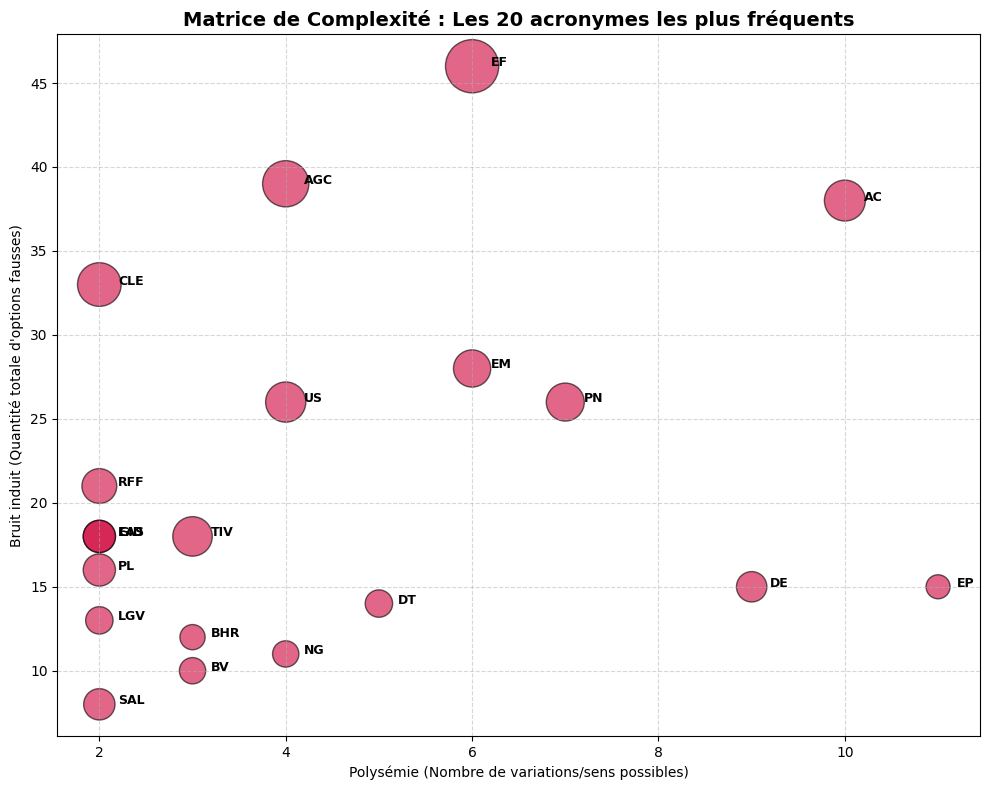

In [31]:
plot_acronym_complexity_scatter(acronym_stats_df)

In [32]:
# =====================================================================
# GRAPHIQUE 6 : Distribution du Taux de Bruit - NOUVEAU
# =====================================================================
def plot_acronym_noise_distribution(acronym_df):
    """
    Description : Histogramme montrant la répartition du taux d'ambiguïté (Faux / (Vrai + Faux))
                  sur l'ensemble des acronymes du dataset.

    Utilité RAG (Attribution) : Donne une vision macroscopique de la qualité des données.
    Si la courbe penche fortement vers 1.0 (100% de bruit), cela prouve que le corpus
    contient énormément de concepts "pièges" justifiant la nécessité d'un modèle d'attribution solide.
    """
    df = acronym_df.copy()
    # Calcul du taux de bruit (éviter division par 0)
    total_options = df['Total True'] + df['Total False']
    df['Noise Ratio'] = np.where(total_options > 0, df['Total False'] / total_options, 0)

    plt.figure(figsize=(10, 6))
    sns.histplot(df['Noise Ratio'], bins=15, kde=True, color='#8A9097')

    plt.title("Distribution de l'Ambiguïté sur l'ensemble du vocabulaire technique", fontsize=14, fontweight='bold')
    plt.xlabel("Taux de Bruit (0.0 = Parfait, 1.0 = Que des options fausses)")
    plt.ylabel("Nombre d'Acronymes concernés")

    # Ligne moyenne
    mean_noise = df['Noise Ratio'].mean()
    plt.axvline(mean_noise, color='#CD0037', linestyle='dashed', linewidth=2, label=f'Moyenne ({mean_noise:.2f})')
    plt.legend()
    plt.tight_layout()
    plt.show()

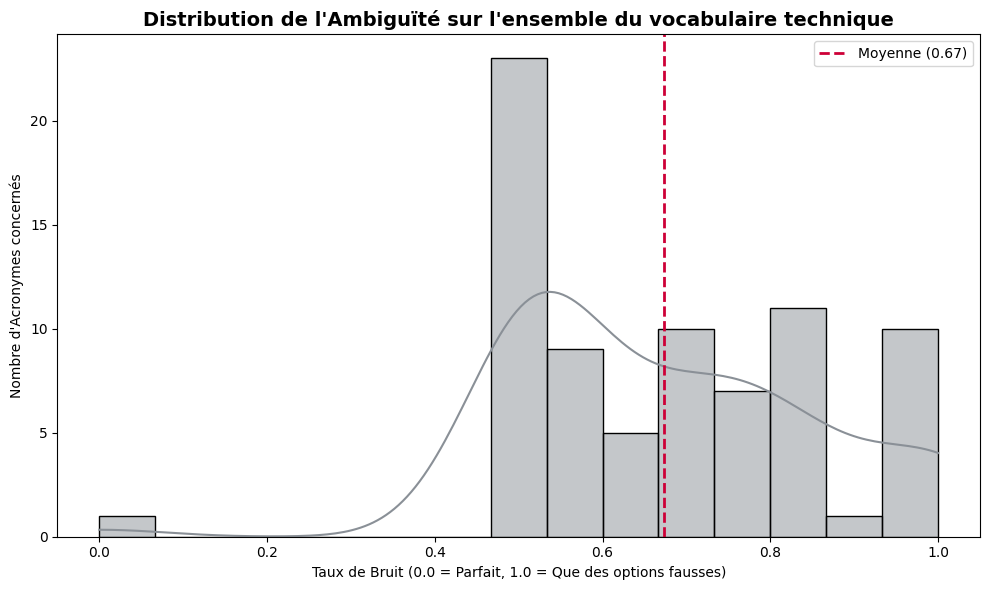

In [33]:
plot_acronym_noise_distribution(acronym_stats_df)

In [46]:
def exporter_donnees_sncf(docs_df, articles_df, city_df, geo_docs_df, acronym_df, options_stat_df, row_stat_df, doc_summary, reserved_df, trues_and_falses_df, dossier_export="dataset_benchmark_rag"):
    """
    Exporte l'ensemble des DataFrames d'analyse du corpus SNCF en fichiers CSV,
    prêts à être utilisés pour la construction du Benchmark RAG.
    """
    # 1. Création du dossier d'exportation s'il n'existe pas
    if not os.path.exists(dossier_export):
        os.makedirs(dossier_export)
        print(f"📁 Création du répertoire de travail : {dossier_export}")

    print("⏳ Lancement de l'exportation des données structurées pour le Benchmark RAG...\n")

    # =====================================================================
    # Fichier 1 : Reconstitution du Corpus
    # =====================================================================
    # Les 'sets' (ensembles) Python ne s'exportent pas bien en CSV.
    # On les convertit en listes (puis en texte) pour que ce soit lisible dans Excel.
    df_corpus_clean = docs_df.copy()
    if 'refs' in df_corpus_clean.columns:
        df_corpus_clean['refs'] = df_corpus_clean['refs'].apply(lambda x: str(list(x)))

    chemin_corpus = os.path.join(dossier_export, "01_SNCF_Corpus_Reconstitue_Pour_RAG.csv")
    df_corpus_clean.to_csv(chemin_corpus, index=False, encoding='utf-8')
    print(f"✅ Fichier 1 généré : {chemin_corpus}")
    print("   -> Utilité : Regrement des catégorie/docs.")


    # =====================================================================
    # Fichier 2 : Articles Réglementaires
    # =====================================================================
    chemin_articles = os.path.join(dossier_export, "02_SNCF_Frequence_Articles_Reglementaires.csv")
    articles_df.to_csv(chemin_articles, index=False, encoding='utf-8')
    print(f"\n✅ Fichier 2 généré : {chemin_articles}")
    print("   -> Utilité : Création de requêtes anti-hallucination (via les articles 'Réservés').")


    # =====================================================================
    # Fichier 3 : Statistiques des Acronymes (Ambiguïté et Bruit)
    # =====================================================================
    chemin_acronymes = os.path.join(dossier_export, "03_SNCF_Complexite_Acronymes_Bruit.csv")
    acronym_df.to_csv(chemin_acronymes, index=False, encoding='utf-8')
    print(f"\n✅ Fichier 3 généré : {chemin_acronymes}")
    print("   -> Utilité : Choix des termes pour le 'Stress-Test' terminologique du RAG.")


    # =====================================================================
    # Fichier 4 : Mentions des Villes (Global)
    # =====================================================================
    chemin_villes = os.path.join(dossier_export, "04_SNCF_Ancrage_Geographique_Villes.csv")
    city_df.to_csv(chemin_villes, index=False, encoding='utf-8')
    print(f"\n✅ Fichier 4 généré : {chemin_villes}")
    print("   -> Utilité : Analyse globale de la couverture géographique du réseau.")


    # =====================================================================
    # Fichier 5 : Diversité Géographique par Document
    # =====================================================================
    chemin_geo_docs = os.path.join(dossier_export, "05_SNCF_Documents_Carrefours_Multi_Villes.csv")
    geo_docs_df.to_csv(chemin_geo_docs, index=False, encoding='utf-8')
    print(f"\n✅ Fichier 5 généré : {chemin_geo_docs}")
    print("   -> Utilité : Cibles parfaites pour les requêtes RAG complexes (multi-sources/comparatives).")

    # =====================================================================
    # Fichier 6 : Statistiques des Options
    # =====================================================================
    chemin_options = os.path.join(dossier_export, "06_SNCF_Statistiques_Options.csv")
    options_stat_df.to_csv(chemin_options, index=False, encoding='utf-8')
    print(f"\n✅ Fichier 6 généré : {chemin_options}")
    print("   -> Utilité : Analyse de la répartition et de la longueur des options par acronyme.")

    # =====================================================================
    # Fichier 7 : Statistiques par Ligne (Row)
    # =====================================================================
    chemin_rows = os.path.join(dossier_export, "07_SNCF_Statistiques_Lignes.csv")
    row_stat_df.to_csv(chemin_rows, index=False, encoding='utf-8')
    print(f"\n✅ Fichier 7 généré : {chemin_rows}")
    print("   -> Utilité : Suivi des métadonnées et statistiques par segment de texte (row).")

    # =====================================================================
    # Fichier 8 : Résumé des Documents
    # =====================================================================
    chemin_doc_summary = os.path.join(dossier_export, "08_SNCF_Resume_Documents.csv")
    doc_summary.to_csv(chemin_doc_summary, index=False, encoding='utf-8')
    print(f"\n✅ Fichier 8 généré : {chemin_doc_summary}")
    print("   -> Utilité : Vue d'ensemble agrégée de chaque document reconstitué.")

    # =====================================================================
    # Fichier 9 : Articles Réservés (Vides/Obsolètes)
    # =====================================================================
    chemin_reserved = os.path.join(dossier_export, "09_SNCF_Articles_Reserves.csv")
    reserved_df.to_csv(chemin_reserved, index=False, encoding='utf-8')
    print(f"\n✅ Fichier 9 généré : {chemin_reserved}")
    print("   -> Utilité : Extraction spécifique des articles obsolètes pour les tests anti-hallucination.")

    # =====================================================================
    # Fichier 10 : Distribution Vrai/Faux
    # =====================================================================
    chemin_trues_falses = os.path.join(dossier_export, "10_SNCF_Distribution_Vrai_Faux.csv")
    trues_and_falses_df.to_csv(chemin_trues_falses, index=False, encoding='utf-8')
    print(f"\n✅ Fichier 10 généré : {chemin_trues_falses}")
    print("   -> Utilité : Évaluation du déséquilibre des classes (Vrai/Faux) dans le dataset d'acronymes.")

    print(f"\n🚀 Succès ! Les 10 fichiers sont prêts à être analysés dans : './{dossier_export}/'")

In [47]:
exporter_donnees_sncf(docs_df, articles_df, city_df, geo_docs_df, acronym_stats_df, options_stat_df, row_stat_df, doc_summary, reserved_df, trues_and_falses_df)

📁 Création du répertoire de travail : dataset_benchmark_rag
⏳ Lancement de l'exportation des données structurées pour le Benchmark RAG...

✅ Fichier 1 généré : dataset_benchmark_rag/01_SNCF_Corpus_Reconstitue_Pour_RAG.csv
   -> Utilité : Regrement des catégorie/docs.

✅ Fichier 2 généré : dataset_benchmark_rag/02_SNCF_Frequence_Articles_Reglementaires.csv
   -> Utilité : Création de requêtes anti-hallucination (via les articles 'Réservés').

✅ Fichier 3 généré : dataset_benchmark_rag/03_SNCF_Complexite_Acronymes_Bruit.csv
   -> Utilité : Choix des termes pour le 'Stress-Test' terminologique du RAG.

✅ Fichier 4 généré : dataset_benchmark_rag/04_SNCF_Ancrage_Geographique_Villes.csv
   -> Utilité : Analyse globale de la couverture géographique du réseau.

✅ Fichier 5 généré : dataset_benchmark_rag/05_SNCF_Documents_Carrefours_Multi_Villes.csv
   -> Utilité : Cibles parfaites pour les requêtes RAG complexes (multi-sources/comparatives).

✅ Fichier 6 généré : dataset_benchmark_rag/06_SNCF_